In [1]:
import pickle

with open("/mnt/beegfs/2a/mn5223/BBP_in_SGD/results/results_v3/all_results.pkl", "rb") as f:
    all_results = pickle.load(f)

print(len(all_results))
print(next(iter(all_results.keys())))

2736
seed0001_i000000_7620f0524956


In [2]:
grouped = {}

for run_id, entry in all_results.items():
    seed = entry["seed"]
    lr = entry["train"]["lr"]
    sigma2_w = entry["train"]["sigma2_w"]

    key = (lr, sigma2_w)

    if key not in grouped:
        grouped[key] = []

    grouped[key].append(entry)

xvals = 1/sigma_w: [3.90625e-03 7.81250e-03 1.56250e-02 3.12500e-02 6.25000e-02 1.25000e-01
 2.50000e-01 5.00000e-01 1.00000e+00 2.00000e+00 4.00000e+00 8.00000e+00]
yvals = lr/batch_size: [3.125e-02 6.250e-02 1.250e-01 2.500e-01 5.000e-01 1.000e+00 2.000e+00
 4.000e+00 8.000e+00 1.600e+01 3.200e+01 6.400e+01]
number of seeds collected per cell:
[[19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]
 [19 19 19 19 19 19 19 19 19 19 19 19]]


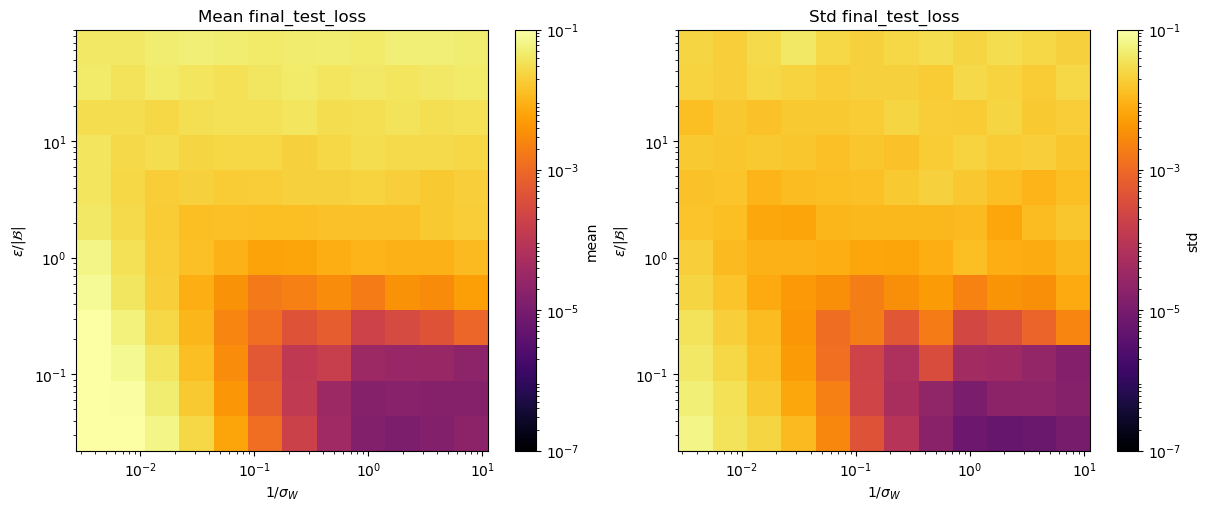

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib inline


# -----------------------------
# Choose what to plot
# -----------------------------
# For the paper-style loss plot, this is the best default:
LOSS_KEY = "final_test_loss"
# If instead you want training loss:
# LOSS_KEY = "final_train_loss"


def final_scalar(x):
    arr = np.asarray(x)
    if arr.ndim == 0:
        return float(arr)
    return float(arr.reshape(-1)[-1])


def guess_loss_key(
    all_results,
    preferred=("final_test_loss", "final_train_loss", "test_loss", "train_loss")
):
    first_key = next(iter(all_results.keys()))
    available = list(all_results[first_key]["npz"].keys())
    print("Available npz keys:", available)

    for k in preferred:
        if k in available:
            print("Using loss key:", k)
            return k

    raise KeyError(f"None of the preferred loss keys {preferred} found. Available: {available}")


def build_phase_diagram_matrices_paper_axes(all_results, loss_key):
    """
    Group runs by:
      x = 1 / sigma_w
      y = lr / batch_size

    and compute mean/std of the chosen loss across seeds.
    """
    grouped = {}

    for run_id, entry in all_results.items():
        train = entry["train"]

        lr = float(train["lr"])
        batch_size = float(train["batch_size"])
        sigma2_w = float(train["sigma2_w"])

        if loss_key not in entry["npz"]:
            continue

        # Paper axes
        T = lr / batch_size                 # epsilon / |B|
        inv_sigma = 1.0 / np.sqrt(sigma2_w)  # 1 / sigma_w

        loss_val = final_scalar(entry["npz"][loss_key])

        key = (inv_sigma, T)
        grouped.setdefault(key, []).append(loss_val)

    if not grouped:
        raise ValueError("No runs were grouped. Check loss_key and all_results.")

    xvals = np.array(sorted({k[0] for k in grouped.keys()}), dtype=float)   # 1/sigma_w
    yvals = np.array(sorted({k[1] for k in grouped.keys()}), dtype=float)   # lr/batch_size

    mean_mat = np.full((len(yvals), len(xvals)), np.nan)
    std_mat = np.full((len(yvals), len(xvals)), np.nan)
    count_mat = np.zeros((len(yvals), len(xvals)), dtype=int)

    for iy, y in enumerate(yvals):
        for ix, x in enumerate(xvals):
            vals = grouped.get((x, y), [])
            if vals:
                vals = np.asarray(vals, dtype=float)
                mean_mat[iy, ix] = vals.mean()
                std_mat[iy, ix] = vals.std()
                count_mat[iy, ix] = len(vals)

    return xvals, yvals, mean_mat, std_mat, count_mat


def centers_to_log_edges(vals):
    """
    Convert log-spaced cell centers into edges for pcolormesh.
    Works also if there is only one value.
    """
    vals = np.asarray(vals, dtype=float)
    logv = np.log10(vals)

    if len(vals) == 1:
        d = 0.5
        edges_log = np.array([logv[0] - d, logv[0] + d])
    else:
        mids = 0.5 * (logv[:-1] + logv[1:])
        left = logv[0] - (mids[0] - logv[0])
        right = logv[-1] + (logv[-1] - mids[-1])
        edges_log = np.concatenate([[left], mids, [right]])

    return 10 ** edges_log


def plot_two_phase_diagrams_paper_style(
    xvals,
    yvals,
    mean_mat,
    std_mat,
    title_left="Mean final loss",
    title_right="Std final loss",
    cmap="inferno",
    vmin=1e-7,
    vmax=1e-1,
):
    """
    Paper-style plotting:
    - x axis: 1/sigma_w (log)
    - y axis: lr/batch_size (log)
    - color scale: log, inferno, fixed to [1e-7, 1e-1]
    """
    x_edges = centers_to_log_edges(xvals)
    y_edges = centers_to_log_edges(yvals)

    # LogNorm cannot plot non-positive values
    mean_plot = np.where(mean_mat > 0, mean_mat, np.nan)
    std_plot = np.where(std_mat > 0, std_mat, np.nan)

    norm = LogNorm(vmin=vmin, vmax=vmax)
    cbar_ticks = [1e-7, 1e-5, 1e-3, 1e-1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    pcm0 = axes[0].pcolormesh(
        x_edges, y_edges, mean_plot,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(r"$1/\sigma_W$")
    axes[0].set_ylabel(r"$\epsilon/|\mathcal{B}|$")
    axes[0].set_title(title_left)
    cbar0 = fig.colorbar(pcm0, ax=axes[0], ticks=cbar_ticks)
    cbar0.set_label("mean")

    pcm1 = axes[1].pcolormesh(
        x_edges, y_edges, std_plot,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel(r"$1/\sigma_W$")
    axes[1].set_ylabel(r"$\epsilon/|\mathcal{B}|$")
    axes[1].set_title(title_right)
    cbar1 = fig.colorbar(pcm1, ax=axes[1], ticks=cbar_ticks)
    cbar1.set_label("std")

    plt.show()


# -----------------------------
# Build and plot
# -----------------------------
loss_key = LOSS_KEY if LOSS_KEY in next(iter(all_results.values()))["npz"] else guess_loss_key(all_results)

xvals, yvals, mean_mat, std_mat, count_mat = build_phase_diagram_matrices_paper_axes(
    all_results,
    loss_key=loss_key,
)

print("xvals = 1/sigma_w:", xvals)
print("yvals = lr/batch_size:", yvals)
print("number of seeds collected per cell:")
print(count_mat)

plot_two_phase_diagrams_paper_style(
    xvals,
    yvals,
    mean_mat,
    std_mat,
    title_left=f"Mean {loss_key}",
    title_right=f"Std {loss_key}",
    cmap="inferno",
    vmin=1e-7,
    vmax=1e-1,
)